In [ ]:
%load_ext autoreload
%autoreload 2
# automatically pick up changes made in src file

LEDGAR DATASET NLP analysis practice

Imports

In [1]:
from pathlib import Path 
from datasets import load_dataset
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import re
import spacy


c:\Users\jagmeet\vsc\py_ld\legal_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Load data
2. encode the labels column into numerical format 
    - label_name (words) is for you: EDA charts, reading mistakes, and writing up findings
    - labels (numbers) is what the model train on 

In [2]:
ds = load_dataset("coastalcph/lex_glue", "ledgar")
print(ds)
raw = Path("../data/raw")
raw.mkdir(parents=True, exist_ok=True)

#create vairable names = for all feature labels 
names = ds["train"].features["label"].names      

for split in ["train", "validation", "test"]:
    df = ds[split].to_pandas() # convert to pandas df
    df["label_name"] = df["label"].map(lambda i: names[i]) # map the same numerical labels
    df.to_parquet(raw / f"{split}.parquet", index=False) # save as parquet
    print(split, df.shape)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
})
train (60000, 3)
validation (10000, 3)
test (10000, 3)


3. Read in the training dataset

In [3]:
train = pd.read_parquet("../data/raw/train.parquet")
train.head(20)


,text,label,label_name
0,Except as otherwise set forth in this Debentur...,97,Waivers
1,No ERISA Event has occurred or is reasonably e...,39,Erisa
2,This Amendment may be executed by one or more ...,26,Counterparts
3,"From time to time, as and when required by the...",45,Further Assurances
4,"Commencing March 7, 2016 and during the Employ...",11,Base Salary
5,All notices required or permitted under this A...,65,Notices
6,"Each Credit Party shall maintain, in all mater...",73,Records
7,"BORROWER HEREBY AGREES TO DEFEND, INDEMNIFY AN...",50,Indemnity
8,"Sublessee leases the Aircraft in its “as is, w...",98,Warranties
9,This Agreement shall be construed and enforced...,47,Governing Laws


4. Basic Checks:
    - shape
    - missing values
    - class imbalances
    - create a column: word_count 
    - observe skews across all 
    - analyse duplicates

In [4]:
train.shape # (60000,3)
train.isna().sum() # no missing values 
train.label.value_counts(normalize = True, dropna = True, sort = True)*100 # significant class imbalances observed 
# ACCURACY should NOT be used as a metric for this dataset. Use F1, Precision and Recall

label
47    5.278333
65    4.155000
26    4.045000
38    3.900000
79    3.013333
        ...   
78    0.196667
3     0.176667
72    0.078333
8     0.051667
14    0.038333
Name: proportion, Length: 100, dtype: float64

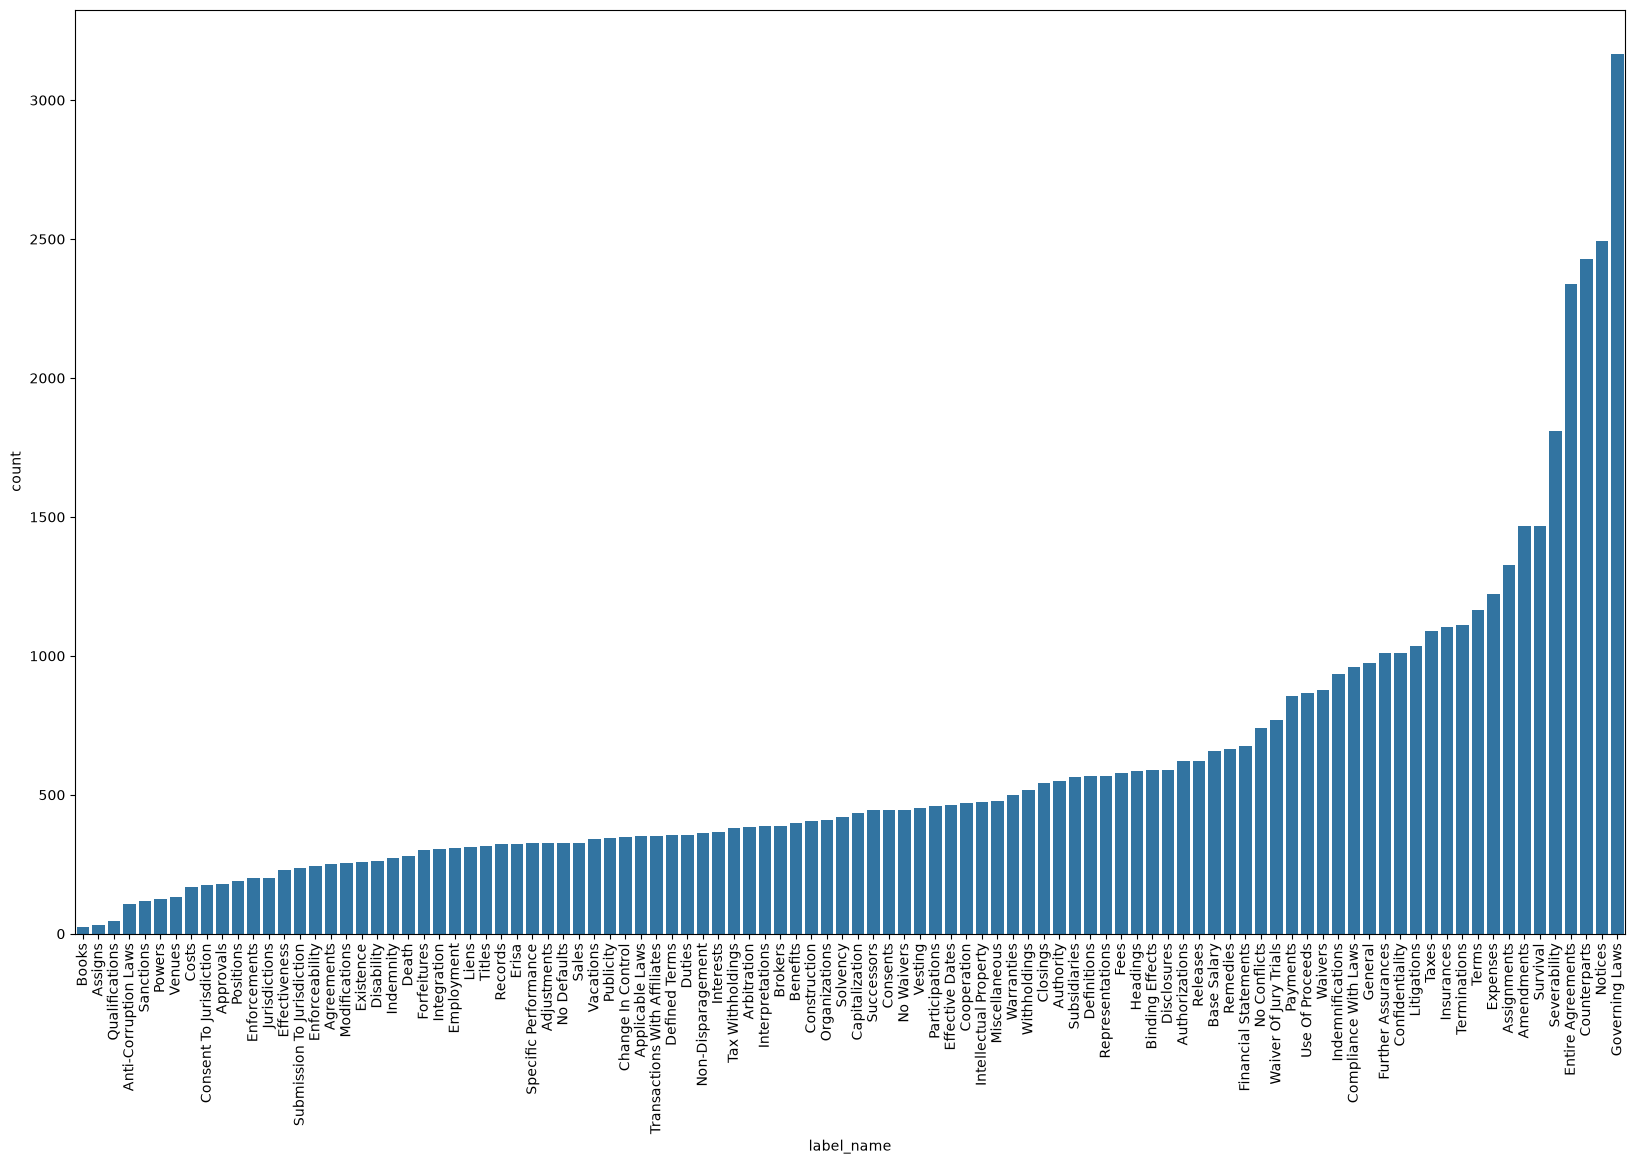

label_name
Governing Laws       3167
Notices              2493
Counterparts         2427
Entire Agreements    2340
Severability         1808
Survival             1469
Amendments           1467
Assignments          1327
Expenses             1224
Terms                1166
Name: count, dtype: int64
label_name
Approvals                  178
Consent To Jurisdiction    175
Costs                      168
Venues                     131
Powers                     125
Sanctions                  118
Anti-Corruption Laws       106
Qualifications              47
Assigns                     31
Books                       23
Name: count, dtype: int64
ratio biggest/smallest: 137.69565217391303


In [5]:
# Visualise the classes:
plt.figure(figsize=(20,12))
sns.countplot(data=train, x="label_name", order = train['label_name'].value_counts(ascending = True).index)
plt.xticks(rotation=90)
plt.show()

# find the class imbalance ratio and the top biggest and smallest
counts = train["label_name"].value_counts()
print(counts.head(10))      # 10 biggest classes
print(counts.tail(10))      # 10 smallest classes
print("ratio biggest/smallest:", counts.max() / counts.min()) # 137.69565217391303 (spread of the data)

In [6]:
# Create a column called word_count that counts the number of words in the text column
train['word_count'] = train['text'].str.split().str.len() # break into individual words and count


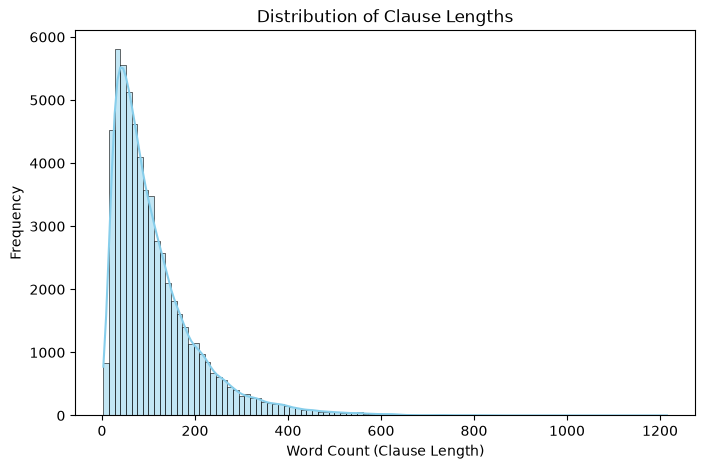

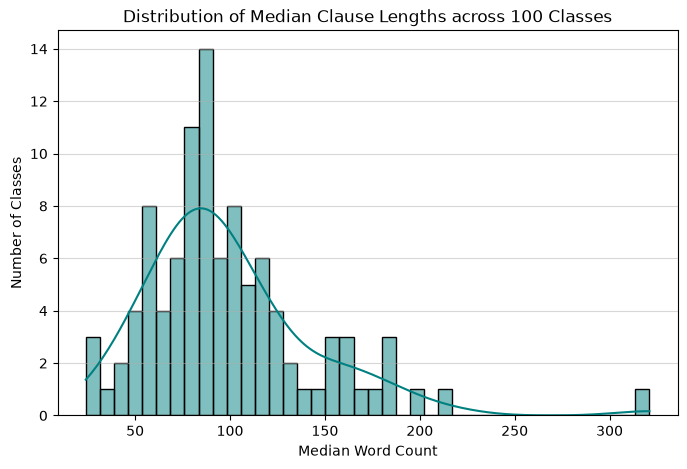

In [7]:
# observe the median word_count for each class and plot - since the wordcount is skewed the means can't be trusted 
plt.figure(figsize=(8, 5))
sns.histplot(data=train, x="word_count", bins=100, kde=True, color="skyblue", edgecolor="black")
plt.xlabel("Word Count (Clause Length)")
plt.ylabel("Frequency")
plt.title("Distribution of Clause Lengths")
plt.show()

# plot histogram of medians 
class_medians = train.groupby('label_name')['word_count'].median()
plt.figure(figsize=(8, 5))
sns.histplot(class_medians, bins=40, kde=True, color="teal", edgecolor="black")
plt.xlabel("Median Word Count")
plt.ylabel("Number of Classes")
plt.title("Distribution of Median Clause Lengths across 100 Classes")
plt.grid(axis='y', alpha=0.5)
plt.show()

Results from steps 4:
- Bar plot (4a): 
    - right skewed, most clauses are shorter (30-50 words peak)
    - long tain - samples are 1200 words - fewer and rare - could be erronous / could be several clauses stuck together 
    - beucase of skew - the median is more reliable than mean - report median and 90th/95th percentile 
    - replot - with log_scale = True axis

- hist plot (4b):
    - most word_counts medians 50-123 words
    - one class is a clear aoutlier with 320 words (investigate)
    - length of text - may tell some classes apart - model would learn with this?
    

In [8]:
train.word_count.describe() # observe the distribution of word counts across all clauses
train.word_count.quantile([0.25, 0.5,0.75, 0.9, 0.95, 0.99]) # observe the distribution of word counts across all clauses

0.25     48.0
0.50     86.0
0.75    148.0
0.90    234.0
0.95    305.0
0.99    471.0
Name: word_count, dtype: float64

- word_count of train[text] -  right-skewed. 
- median clause is 86 words 
- lower quartile half : 48 - 148 words
- 0.95 quantile: 5% > 305 words 
- 0.99 quantile: 1% > 471 - some > 1,000. 

- The longest clauses should be checked for several clauses merged together. 
- Around 10–15% of clauses are longer than the roughly 200-word limit of the embedding model planned = they will be truncated - so observe now 

In [9]:
# print the 5 longest clauses:
train.nlargest(5, 'word_count')[['label_name', 'word_count', 'text']]

#find the rows which have text which will be truncated by the model - i.e. those with word_count > (200-512 - dep. on model)
train[(train['word_count'] > 200)][['label_name', 'word_count', 'text']] # 8,629


,label_name,word_count,text
4,Base Salary,211,"Commencing March 7, 2016 and during the Employ..."
7,Indemnity,241,"BORROWER HEREBY AGREES TO DEFEND, INDEMNIFY AN..."
13,Litigations,218,"Except as disclosed in the SEC Reports, there ..."
32,Entire Agreements,202,This Agreement taken together with the offer l...
39,Vesting,248,"Subject to Section 5.4(c), shares issued pursu..."
...,...,...,...
59965,General,334,If the Company proposes to file a Registration...
59972,Taxes,209,"To the knowledge of the Applicant, each of Hol..."
59973,Notices,294,"Except as otherwise provided herein, whenever ..."
59980,Liens,427,"Borrower shall not, and shall not permit any W..."


4. (continued) Observe duplicates across all ds

In [10]:
train.text = train.text.str.lower() # standardidise the outputs for following checks

train["text"].duplicated().sum() # 64

duplicates = train[train["text"].duplicated(keep = False)] # same text, differing labels (labels noise or issues in classification)
conflicting_labels = duplicates.groupby(['text'])['label'].nunique() # text with conflicting labels  
print("texts with conflicting labels:", (conflicting_labels > 1).sum())

conflict_texts = conflicting_labels[conflicting_labels > 1].index
train[train["text"].isin(conflict_texts)][["label_name", "text"]].sort_values("text")

texts with conflicting labels: 3


,label_name,text
405,No Waivers,the failure of a party to insist upon strict a...
31400,Waivers,the failure of a party to insist upon strict a...
9031,Qualifications,the general partner and each of the partnershi...
17706,Existence,the general partner and each of the partnershi...
39187,Applicable Laws,this agreement shall be governed by and constr...
57827,Governing Laws,this agreement shall be governed by and constr...


Result of duplicate analysis:
- Train contains 64 duplicate clauses (about 0.1%), 3 of which have conflicting labels. 
- Duplicates were removed and the conflicting clauses dropped, as their true label can't be determined

- Three clauses appear with conflicting labels: 
    - No Waivers/Waivers, Applicable Laws/Governing Laws, and Qualifications/Existence. 
    - In each case the labels overlap in meaning. 
    - LEDGAR labels come from contract headings, so the same wording can carry different labels. 
    - This is a source of label noise, and these pairs are likely to be confused by the model

    Thus remove all 6 rows as they are sources of confusion for the model

In [11]:
# drop conflicing label duplicates
train = train[~train["text"].isin(conflict_texts)]
# duplicate check should be 64-3 = 61
train["text"].duplicated().sum() # 61
# remove extra copies of duplicates 
train = train.drop_duplicates(subset="text").reset_index(drop=True)

#final duplicate check 
train["text"].duplicated().sum() # 61


np.int64(0)

4 (final part) - check for leakage of the same examples of text from train in test

In [12]:
test = pd.read_parquet("../data/raw/test.parquet")
print("test clauses also in train:", test["text"].isin(train["text"]).sum())

test clauses also in train: 0


5. Bagging words, TF-IDF, Word2Vec = CLEANING
    - text preprocessing: lowercasing, remove special characters, tokenising, stop words, stemming, lemmatisation
    - Bag of words - turning text into word counts - TFIDF will work of this foundation 
    - Word2Vec - use sentence embeddings downstream 


## Text Preprocessing 
1. Read a sample of raw clauses. Note every odd pattern: numbers, money, (ii), punctuation and so on.

2. Write your cleaning function with re. This takes one clause and returns a cleaner version:

    - lowercase
    - money becomes moneytoken
    - numbers become numtoken
    - remove bracketed list markers like (a) and (ii)
    - remove remaining punctuation and symbols
    - collapse extra spaces
    
    - CALL FROM SRC FILE WHICH REPRODUCABLE CLEANING SCRIPTS 


3. Lemmatise with spaCy. Feed it the cleaned clauses, and get back each clause with words in base form. spaCy tokenises internally to do this.

4. Save it. Add the result as a clean column and save it to data/processed, so you only run the slow lemmatising once.

5. Find your legal stop words. Run the counting method (CountVectorizer, binary) on the clean column to see which words appear in most clauses. Build your stop-word list, keeping "no" and "not".

6. TF-IDF. Give TfidfVectorizer the clean column and your stop-word list. It tokenises, removes stop words and builds the numbers. This happens in the baseline notebook, as the first half of your model.

In [13]:
train.text
# different types of termanology to consider when cleaning: dates written in long format, money, numbers, section refrences, numbering in lists, addresses, phone numbers, emails, urls


0        except as otherwise set forth in this debentur...
1        no erisa event has occurred or is reasonably e...
2        this amendment may be executed by one or more ...
3        from time to time, as and when required by the...
4        commencing march 7, 2016 and during the employ...
                               ...                        
59928    any notice required to be delivered to the com...
59929    this agreement may be terminated by any purcha...
59930    by signing this agreement, you agree to keep b...
59931    the loan documents cannot be amended, terminat...
59932    for purposes of determining lenders' obligatio...
Name: text, Length: 59933, dtype: str

In [14]:
# import cleaning function 
import sys; sys.path.append('..')
from src.clean import clean_text

# text the cleaning function first:
testing_text = 'Notices: (a) send to legal@acme.com within 30 days; (ii) pay $1,250,000.00 per Section 5.2 of the Agreement.'
result = clean_text(testing_text)

print(result)

notices send to emailtoken within numtoken days pay moneytoken per section numtoken of the agreement


In [15]:
# clean all files: train, validation , test
splits = {
    "train": train,
    "validation": pd.read_parquet("../data/raw/validation.parquet"),
    "test": pd.read_parquet("../data/raw/test.parquet"),
}

for name, df in splits.items():
    df["clean_text"] = df["text"].apply(clean_text)
    print(name, df.shape)

train (59933, 5)
validation (10000, 4)
test (10000, 4)


tokenise and lemmatise using spacy lemmatisation model

In [16]:
# Load spaCy's small English model =  creates `nlp`: a chain of steps that run in order on any text you give it.
# chain: tokenizer -> tagger -> attribute_ruler -> lemmatizer -> parser -> ner (turned of parser & ner)
#  lemmatising does not need them +  turning them off makes it much faster.
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"]) # disable parser and ner to speed up processing
# ignores the grammatical structure (syntax) that connects words into phrases and sentences
import en_core_web_sm
nlp = en_core_web_sm.load()


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -------------- ------------------------- 4.7/12.8 MB 32.1 MB/s eta 0:00:01
     ---------------------------------- ---- 11.3/12.8 MB 31.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 30.6 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [17]:
# get lemmatiser & test (ensure it tokenises too)
doc = nlp(result)
print([token.lemma_ for token in doc])


['notice', 'send', 'to', 'emailtoken', 'within', 'numtoken', 'day', 'pay', 'moneytoken', 'per', 'section', 'numtoken', 'of', 'the', 'agreement']


In [18]:
# Call lemmetizer function to lemmatize the cleaned clauses and add a new column to the dataframe
import sys; sys.path.append('..')
from src.lemmetizer import lemmatize_clauses

In [19]:
processed = Path("../data/processed")
processed.mkdir(parents=True, exist_ok=True)

for name, df in splits.items(): # .items (loop over dictinoary) gives both the key and value, i.e. name and df
    df = lemmatize_clauses(df, nlp) # tokenise + lemmatise
    df.to_parquet(processed / f"proc_{name}.parquet", index=False) # save
    print(name, df.shape)

train (59933, 6)
validation (10000, 5)
test (10000, 5)


SANITY CHECK AFTER ALL STEPS of preprocessing
- cleaning - removed apostrophe 
- lemmetizer removes lone random letters:
    - won't --> won t --> win (from lemmetizer) - so go back and check how many informal contractions are found in the text column

In [ ]:
train[train.text.str.contains("'t")] #  no rows therefore no contractions have been used, all meaning remain the same in setnences of contractions, e.g. "don't" = "do not", "can't" = "cannot", "won't" = "will not"

,text,label,label_name,word_count,clean_text,lemmatized_text


STOP WORDS


In [ ]:
# extract english stop words to find out which need to be made exempt from the list:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
print(f"English stop words: {len(ENGLISH_STOP_WORDS)}")
sorted_stop_words = sorted(list(ENGLISH_STOP_WORDS))

# Write each word to a new line in a text file
with open('sklearn_english_stop_words.txt', 'w', encoding='utf-8') as file:
    for word in sorted_stop_words:
        file.write(f"{word}\n")


English stop words: 318


- Check stop words - if they turn up in specific label name topics - then they show seperability = keep 
- Words such as amount, due, full, against, first and per were left in the stop-word list. They are only moderately concentrated in some classes; keeping them can be tested later on validation


In [84]:
for i in ("amongst", "per", "'t", "full", "against", "without", "within", "between", "among", "first", "except", "otherwise", "bill"):
        print(f"Clauses containing '{i}': {train[train.text.str.contains(i)].shape[0]*100/len(train):.2f}%")
        train[train.text.str.contains(i)]['label_name'].value_counts(normalize=True).round(2)*100 #  no rows therefore no amongst has been used, all meaning remain the same in setnences of amongst, e.g. "amongst" = "among"


Clauses containing 'amongst': 0.01%
Clauses containing 'per': 49.83%
Clauses containing ''t': 0.00%
Clauses containing 'full': 12.79%
Clauses containing 'against': 9.78%
Clauses containing 'without': 19.43%
Clauses containing 'within': 5.19%
Clauses containing 'between': 6.58%
Clauses containing 'among': 2.63%
Clauses containing 'first': 4.00%
Clauses containing 'except': 19.07%
Clauses containing 'otherwise': 17.22%
Clauses containing 'bill': 0.32%


list of words exempt from the stop words as they change the meaning of sentences, if they are removed, they alter the meaning of texts and thus alter classification capabilities:
- Negations: they flip meaning
- no · not · nor · never · neither · none · nothing · nobody · without · cannot

- Clause-name words
- further (from Further Assurances) · interest (from Interests)


In [104]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words_set = set(ENGLISH_STOP_WORDS)

# KEEP in text (remove them from the stop-word list)
exempt_words = {'no', 'not', 'nor', 'never', 'neither', 'none', 'nothing',
                'nobody', 'without', 'cannot', 'further', 'interest'}

# Common legal words to REMOVE from the text (add them to the stop-word list)
legal_words = {'shall', 'party', 'agreement', 'hereof', 'hereunder', 'herein'}

# 4. Final list: built-in + legal words - exemptions
stop_words_set = (stop_words_set | legal_words) - exempt_words

print(type(stop_words_set), len(stop_words_set))

<class 'set'> 311


TF-IDF & Stop Words
- Validation and test play the role of future data the model has never seen. Their whole job is to tell you how the model will do in real life.
- only fit_transform - train
- test and validation - transform ONLY 

In [120]:
# read in files:
proc_train = pd.read_parquet("../data/processed/proc_train.parquet")
proc_val = pd.read_parquet("../data/processed/proc_validation.parquet")
proc_test = pd.read_parquet("..//data/processed/proc_test.parquet")

In [96]:
proc_train.columns 

Index(['text', 'label', 'label_name', 'word_count', 'clean_text',
       'lemmatized_text'],
      dtype='str')

In [105]:
import sys; sys.path.append('..')
from src.tf_idf import tfid

vectorizer= tfid(stop_words_set)
# fit and transform the train dataset:
x_train = vectorizer.fit_transform(proc_train.lemmatized_text)

# transform the learned vectorizer on validation and test - no leakage
x_val = vectorizer.transform(proc_val.lemmatized_text)
x_test = vectorizer.transform(proc_test.lemmatized_text)



In [ ]:
names = vectorizer.get_feature_names_out()



(59933, 95613)
4347635
0.0007587000523644187


observation of sparse matrix

In [113]:
i = 0                                   # row number of the clause to look at
row = x_train[i]
words = names[row.indices]              # the columns this clause actually uses
scores = row.data                       # their TF-IDF scores

print(train["lemmatized_text"].iloc[i])
print(pd.Series(scores, index=words).sort_values(ascending=False).head(15))
pd.DataFrame(x_train[:5, :10].toarray(), columns=names[:10])

except as otherwise set forth in this debenture the company for itself and its legal representative successor and assign expressly waive presentment protest demand notice of dishonor notice of nonpayment notice of maturity notice of protest presentment for the purpose of accelerate maturity and diligence in collection
presentment             0.246165
protest                 0.241223
maturity                0.219173
debenture company       0.216023
diligence collection    0.216023
maturity notice         0.212761
protest demand          0.209936
nonpayment notice       0.203197
accelerate maturity     0.193986
notice nonpayment       0.188531
dishonor notice         0.184996
presentment protest     0.181274
assign expressly        0.180602
company legal           0.178110
waive presentment       0.173864
dtype: float64


,aa,aaa,aaa accordance,aaa administrative,aaa arbitration,aaa arbitrator,aaa commercial,aaa designate,aaa dispute,aaa effect
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The TF-IDF matrix has 95,613 features, but each clause uses about 73 of them on average; the matrix is over 99.9% empty, so it is stored as a sparse matrix."

Model

In [ ]:
# Establish x_train, x_test, x_val, y_test, y_train, y_val: y is the label column of each split: y_train, y_val and y_test. 
y_train = proc_train.label
y_val = proc_val.label
y_test = proc_test.label 

# pairs each number with its name, then makes a lookup dictionary
#zip lines up the two columns side by side
label_names = dict(zip(proc_train["label"], proc_train["label_name"])) 

Call model from SRC file

In [142]:
import sys; sys.path.append('..')
from src.multi_class_lr_softmax import MultiClassLogisticRegression

# model and evaluation metrics
lr = MultiClassLogisticRegression(x_train, x_val, x_test,
                                  y_train, y_val, y_test,
                                  C=1.0, class_weight=None)

lr.train() # learn weights
train_preds, train_scores = lr.evaluate_train() #  the model guesses train labels, and they're marked

val_preds, val_scores = lr.validate() #the model guesses validation labels, and they're marked
report = lr.report(val_preds)  # gets precision, recall and F1 for each of the 100 classes, as a dictionary

# perform report analysis on validation set: reports model activity on unseen data,; shows authentic weaknesses

Settings: C=1.0, class_weight=None
Training multiclass softmax logistic regression...
Number of classes: 100
train      accuracy 0.9018 | macro F1 0.8504 | micro F1 0.9018
validation accuracy 0.8478 | macro F1 0.7709 | micro F1 0.8478


ValueError: Number of classes, 99, does not match size of target_names, 10000. Try specifying the labels parameter

In [ ]:
report_df = pd.DataFrame(report).T # turns it into a table. .Transpose flips it =  class converted to row
report_df = report_df.iloc[:-3] # drop accuracy, macro avg, weighted rows (they arent classes)
report_df.index = report_df.index.astype(int).map(label_names)   # 47 -> "Governing Laws"
report_df.sort_values("f1-score").head(10)  # the 10 worst clause types